In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

In [65]:
df = []
base_path = os.getcwd()
data_path = os.path.join(base_path, "data")
os.makedirs(data_path, exist_ok = True)

In [66]:
# jak już masz folder data a w nim pobrane dane
df = pd.read_csv(f"{os.path.join(data_path, 'CLEAN_House4.csv')}")
df.describe()

,Unix,Aggregate,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8,Appliance9,Issues
count,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00
mean,1408333614.94,381.22,9.83,61.18,37.35,4.21,10.58,13.65,23.24,9.58,10.72,0.01
std,15477991.99,428.32,24.98,73.08,60.20,96.12,151.20,22.44,33.56,92.99,142.79,0.10
min,1381486757.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1396605135.00,194.00,0.00,0.00,0.00,0.00,0.00,7.00,0.00,2.00,0.00,0.00
50%,1408624761.00,298.00,0.00,0.00,0.00,0.00,0.00,9.00,0.00,2.00,0.00,0.00
75%,1421313246.50,473.00,0.00,134.00,123.00,0.00,0.00,11.00,62.00,2.00,0.00,0.00
max,1436263058.00,65663.00,3968.00,3791.00,3717.00,3100.00,2728.00,2059.00,2548.00,3592.00,2560.00,1.00


In [67]:
MAX_REALISTIC_POWER = 20000 

# 1. Znajdujemy indeksy (numery wierszy), w których Aggregate zwariowało
anomalies_idx = df[df['Aggregate'] > MAX_REALISTIC_POWER].index

# 2. Dla tych konkretnych wierszy, we wszystkich kolumnach (znak ':') wstawiamy NaN
df.loc[anomalies_idx, :] = np.nan

# 3. Wywołujemy interpolację na całym DataFrame 
# (uzupełni to luki we wszystkich kolumnach na raz, opierając się na wierszu wyżej i niżej)
df = df.interpolate(method='linear')

C:\Users\Jakub\AppData\Local\Temp\ipykernel_7372\1585752334.py:11: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear')


In [ ]:
mapping = {
    'Appliance1': 'Fridge_Freezer',
    'Appliance2': 'Chest_Freezer',
    'Appliance3': 'Upright_Freezer',
    'Appliance4': 'Tumble_Dryer',
    'Appliance5': 'Washing_Machine',
    'Appliance6': 'Dishwasher',
    'Appliance7': 'Computer',
    'Appliance8': 'TV',
    'Appliance9': 'Electric_Heater'
}
df.rename(columns=mapping, inplace=True)
df['Time'] = pd.to_datetime(df['Time'])
df.index = df['Time']

In [69]:
appliances = ['Fridge_Freezer', 'Chest_Freezer', 'Upright_Freezer',
              'Tumble_Dryer', 'Washing_Machine', 'Dishwasher',
              'Computer', 'TV', 'Electric_Heater']
target_cols = [f'{app}_on' for app in appliances]

thresholds = {
    'Fridge_Freezer': 30,
    'Chest_Freezer': 50,
    'Upright_Freezer': 50,
    'Tumble_Dryer': 5,       
    'Washing_Machine': 5,
    'Dishwasher': 5,
    'Computer': 30,           # Zgodnie z Twoim opisem > 15W
    'TV': 15,                 # Zgodnie z Twoim opisem > 15W
    'Electric_Heater': 100     # Zgodnie z Twoim opisem > 15W
}

for app in appliances:
    df[f'{app}_on'] = np.where(df[app] > thresholds[app], 1, 0)

# for app in appliances:
#     threshold = df[app].quantile(0.25)

#     df[f'{app}_on'] = np.where(df[app] > threshold, 1, 0)

In [70]:
pd.set_option('display.float_format', '{:.2f}'.format)
percentiles = [0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 0.9999]
df[df.columns[2:13]].describe(percentiles=percentiles)

,Aggregate,Fridge_Freezer,Chest_Freezer,Upright_Freezer,Tumble_Dryer,Washing_Machine,Dishwasher,Computer,TV,Electric_Heater,Issues
count,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00
mean,381.18,9.83,61.18,37.35,4.21,10.58,13.65,23.24,9.58,10.72,0.01
std,425.37,24.98,73.08,60.20,96.12,151.20,22.44,33.56,92.99,142.79,0.10
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,194.00,0.00,0.00,0.00,0.00,0.00,7.00,0.00,2.00,0.00,0.00
50%,298.00,0.00,0.00,0.00,0.00,0.00,9.00,0.00,2.00,0.00,0.00
75%,473.00,0.00,134.00,123.00,0.00,0.00,11.00,62.00,2.00,0.00,0.00
90%,598.00,51.00,150.00,129.00,0.00,0.00,12.00,78.00,2.00,0.00,0.00
95%,764.00,53.00,161.00,132.00,4.00,0.00,79.00,86.00,2.00,0.00,0.00
99%,2546.00,54.00,172.00,144.00,4.00,6.00,117.00,96.00,19.00,0.00,0.00


Dane pełne bez ubytków

### Struktura danych
| Nazwa Kolumny | Urządzenie | Typ Danych | Jednostka | Opis |
| :--- | :--- | :--- | :--- | :--- |
| **Time** | Znacznik czasu | Datetime | YYYY-MM-DD HH:MM:SS | Próbkowanie co ok. 8s. |
| **Unix** | Czas Unix | Integer | Sekundy (s) | Timestamp w formacie POSIX. |
| **Aggregate** | Całkowite zużycie domu | Float | Waty (W) | Główna zmienna wejściowa modelu (Main Meter). |
| **Fridge_Freezer** | Lodówko-zamrażarka | Float | Waty (W) | Praca cykliczna, sterowana termostatem. |
| **Chest_Freezer** | Zamrażarka skrzyniowa | Float | Waty (W) | Stabilne piki mocy podczas pracy sprężarki. |
| **Upright_Freezer** | Zamrażarka pionowa | Float | Waty (W) | Kolejne urządzenie chłodnicze o stałym profilu. |
| **Tumble_Dryer** | Suszarka do ubrań | Float | Waty (W) | Bardzo wysoka moc (>2000W), praca ciągła. |
| **Washing_Machine** | Pralka | Float | Waty (W) | Zmienny profil: grzanie wody vs. praca silnika. |
| **Dishwasher** | Zmywarka | Float | Waty (W) | Charakterystyczne skoki mocy w cyklach grzania. |
| **Computer** | Stanowisko komputerowe | Float | Waty (W) | Zasilacze impulsowe, niski szum tła. |
| **TV** | Stanowisko TV | Float | Waty (W) | Telewizor i sprzęt towarzyszący. |
| **Electric_Heater** | Grzejnik elektryczny | Float | Waty (W) | Obciążenie rezystancyjne, wysoka, stała moc. |

**Źródło danych:** Murray, D., Stankovic, L., & Stankovic, V. (2017). *REFIT Smart Home dataset*. Loughborough University. [DOI: 10.4121/uuid:5bd1068a-6625

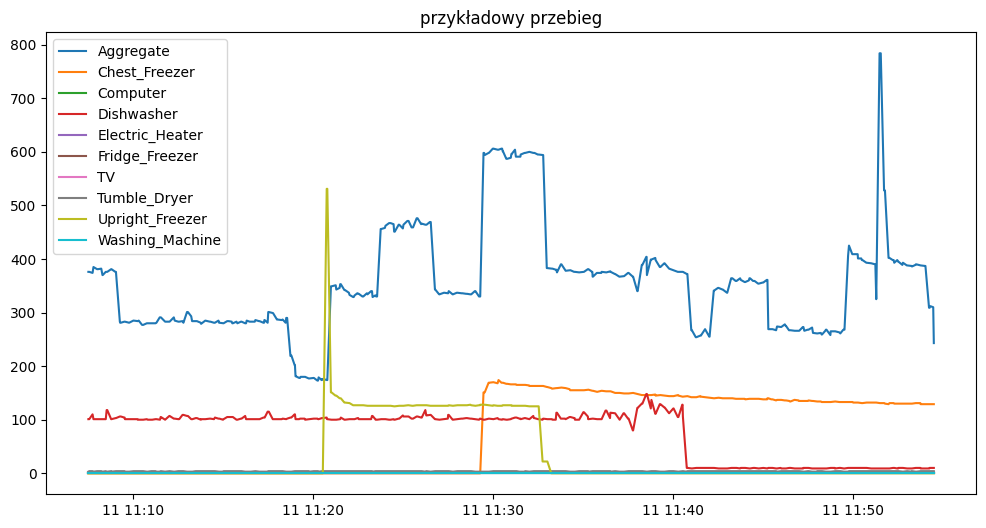

In [71]:
df_small = df.iloc[500:1000]

plt.figure(figsize=(12, 6))
plt.title("przykładowy przebieg")
plt.plot(df_small['Time'], df_small['Aggregate'], label = 'Aggregate')
plt.plot(df_small['Time'], df_small['Chest_Freezer'], label = 'Chest_Freezer')
plt.plot(df_small['Time'], df_small['Computer'], label = 'Computer')
plt.plot(df_small['Time'], df_small['Dishwasher'], label = 'Dishwasher')
plt.plot(df_small['Time'], df_small['Electric_Heater'], label = 'Electric_Heater')
plt.plot(df_small['Time'], df_small['Fridge_Freezer'], label = 'Fridge_Freezer')
plt.plot(df_small['Time'], df_small['TV'], label = 'TV')
plt.plot(df_small['Time'], df_small['Tumble_Dryer'], label = 'Tumble_Dryer')
plt.plot(df_small['Time'], df_small['Upright_Freezer'], label = 'Upright_Freezer')
plt.plot(df_small['Time'], df_small['Washing_Machine'], label = 'Washing_Machine')
plt.legend()
plt.show()

In [72]:
df.describe()

,Time,Unix,Aggregate,Fridge_Freezer,Chest_Freezer,Upright_Freezer,Tumble_Dryer,Washing_Machine,Dishwasher,Computer,...,Issues,Fridge_Freezer_on,Chest_Freezer_on,Upright_Freezer_on,Tumble_Dryer_on,Washing_Machine_on,Dishwasher_on,Computer_on,TV_on,Electric_Heater_on
count,6760507,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,...,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00,6760511.00
mean,2014-08-18 03:46:49.128529920,1408333614.94,381.18,9.83,61.18,37.35,4.21,10.58,13.65,23.24,...,0.01,0.18,0.43,0.29,0.00,0.01,0.76,0.27,0.01,0.01
min,2013-10-11 10:19:17,1381486757.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2014-04-04 09:52:07.500000,1396605135.00,194.00,0.00,0.00,0.00,0.00,0.00,7.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
50%,2014-08-21 12:38:51,1408624761.00,298.00,0.00,0.00,0.00,0.00,0.00,9.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
75%,2015-01-15 09:13:59.500000,1421313246.50,473.00,0.00,134.00,123.00,0.00,0.00,11.00,62.00,...,0.00,0.00,1.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00
max,2015-07-07 09:57:38,1436263058.00,18853.00,3968.00,3791.00,3717.00,3100.00,2728.00,2059.00,2548.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
std,NaN,15477991.99,425.37,24.98,73.08,60.20,96.12,151.20,22.44,33.56,...,0.10,0.39,0.50,0.45,0.06,0.10,0.42,0.44,0.10,0.07


### Trening set prep

#### Features
| Nazwa Cechy | Opis | Rola w modelu |
| :--- | :--- | :--- |
| **Aggregate** | Bieżący odczyt mocy całkowitej (t) | Główny sygnał wejściowy. |
| **Agg_Lag1, Lag2, Lag3** | Moc z poprzednich 3 odczytów (t-1, t-2, t-3) | Pozwala modelowi dostrzec kształt zbocza (narastanie/spadek). |
| **Power_Delta** | Różnica: $Aggregate(t) - Aggregate(t-1)$ | Kluczowa do wykrywania momentów włączenia/wyłączenia urządzeń. |
| **Roll_Mean_5min** | Średnia krocząca z ostatnich 5 minut | Odfiltrowuje szum i pokazuje poziom bazowy (baseload). |
| **Roll_Std_5min** | Odchylenie standardowe z ostatnich 5 minut | Pomaga odróżnić urządzenia stabilne od tych o zmiennym poborze. |
| **Hour** | Godzina doby (0-23) | Uwzględnia behawiorystykę mieszkańców (np. pranie rzadziej w nocy). |
| **Day_of_Week** | Dzień tygodnia (0-6) | Pozwala wykryć wzorce weekendowe vs. dni robocze. |

#### Targets
| Target (Binarny 0/1) | Urządzenie docelowe | Próg detekcji (ON) |
| :--- | :--- | :--- |
| **Fridge_Freezer_on** | Lodówko-zamrażarka | > 15W |
| **Chest_Freezer_on** | Zamrażarka skrzyniowa | > 15W |
| **Upright_Freezer_on** | Zamrażarka pionowa | > 15W |
| **Tumble_Dryer_on** | Suszarka do ubrań | > 15W |
| **Washing_Machine_on** | Pralka | > 15W |
| **Dishwasher_on** | Zmywarka | > 15W |
| **Computer_on** | Stanowisko komputerowe | > 15W |
| **TV_on** | Stanowisko TV | > 15W |
| **Electric_Heater_on** | Grzejnik elektryczny | > 15W |

---

In [75]:
Train_set = pd.DataFrame()
Train_set['Aggregate'] = df[['Aggregate']]

#Train_set['Time'] = df['Time'].dt.hour + df['Time'].dt.minute / 60
#Train_set.index = df['Time']

Train_set['month'] = df['Time'].dt.month
Train_set['day_of_week'] = df['Time'].dt.dayofweek

# Czas jako liczba od 0 do 1 (postęp doby)
Train_set['day_progress'] = (df['Time'].dt.hour * 3600 +
                             df['Time'].dt.minute * 60 +
                             df['Time'].dt.second) / 86400

Train_set['agg_lag_1'] = df['Aggregate'].shift(1)
Train_set['agg_lag_2'] = df['Aggregate'].shift(2)
Train_set['agg_lag_3'] = df['Aggregate'].shift(3)
Train_set['agg_lag_4'] = df['Aggregate'].shift(4)
Train_set['agg_lag_5'] = df['Aggregate'].shift(5)

Train_set['power_delta'] = df['Aggregate'].diff()

window_size = 37
Train_set['roll_mean_5min'] = df['Aggregate'].rolling(window=window_size).mean()
Train_set['roll_std_5min'] = df['Aggregate'].rolling(window=window_size).std()

window_size = 74
Train_set['roll_mean_10min'] = df['Aggregate'].rolling(window=window_size).mean()
Train_set['roll_std_10min'] = df['Aggregate'].rolling(window=window_size).std()


window_size = 222
Train_set['roll_mean_30min'] = df['Aggregate'].rolling(window=window_size).mean()
Train_set['roll_std_30min'] = df['Aggregate'].rolling(window=window_size).std()

Train_set = Train_set.join(df[target_cols])

In [76]:
Train_set.info()
print(Train_set.isnull().sum())
Train_set.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6760523 entries, 2013-10-11 10:19:17 to 2015-07-07 09:57:38
Data columns (total 25 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Aggregate           float64
 1   month               float64
 2   day_of_week         float64
 3   day_progress        float64
 4   agg_lag_1           float64
 5   agg_lag_2           float64
 6   agg_lag_3           float64
 7   agg_lag_4           float64
 8   agg_lag_5           float64
 9   power_delta         float64
 10  roll_mean_5min      float64
 11  roll_std_5min       float64
 12  roll_mean_10min     float64
 13  roll_std_10min      float64
 14  roll_mean_30min     float64
 15  roll_std_30min      float64
 16  Fridge_Freezer_on   int64  
 17  Chest_Freezer_on    int64  
 18  Upright_Freezer_on  int64  
 19  Tumble_Dryer_on     int64  
 20  Washing_Machine_on  int64  
 21  Dishwasher_on       int64  
 22  Computer_on         int64  
 23  TV_on               int6

,Aggregate,month,day_of_week,day_progress,agg_lag_1,agg_lag_2,agg_lag_3,agg_lag_4,agg_lag_5,power_delta,...,roll_std_30min,Fridge_Freezer_on,Chest_Freezer_on,Upright_Freezer_on,Tumble_Dryer_on,Washing_Machine_on,Dishwasher_on,Computer_on,TV_on,Electric_Heater_on
Time,,,,,,,,,,,,,,,,,,,,,
2013-10-11 10:19:17,596.00,10.00,4.00,0.43,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1,1,0,0,0,1,0,0,0
2013-10-11 10:19:32,593.00,10.00,4.00,0.43,596.00,NaN,NaN,NaN,NaN,-3.00,...,NaN,1,1,0,0,0,1,0,0,0
2013-10-11 10:19:46,594.00,10.00,4.00,0.43,593.00,596.00,NaN,NaN,NaN,1.00,...,NaN,1,1,0,0,0,1,0,0,0
2013-10-11 10:20:01,601.00,10.00,4.00,0.43,594.00,593.00,596.00,NaN,NaN,7.00,...,NaN,1,1,0,0,0,1,0,0,0
2013-10-11 10:20:15,597.00,10.00,4.00,0.43,601.00,594.00,593.00,596.00,NaN,-4.00,...,NaN,1,1,0,0,0,1,0,0,0


In [77]:
Train_set = Train_set.dropna()
Train_set.info()
print(Train_set.isnull().sum())
Train_set.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6760286 entries, 2013-10-11 10:40:13 to 2015-07-07 09:57:38
Data columns (total 25 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Aggregate           float64
 1   month               float64
 2   day_of_week         float64
 3   day_progress        float64
 4   agg_lag_1           float64
 5   agg_lag_2           float64
 6   agg_lag_3           float64
 7   agg_lag_4           float64
 8   agg_lag_5           float64
 9   power_delta         float64
 10  roll_mean_5min      float64
 11  roll_std_5min       float64
 12  roll_mean_10min     float64
 13  roll_std_10min      float64
 14  roll_mean_30min     float64
 15  roll_std_30min      float64
 16  Fridge_Freezer_on   int64  
 17  Chest_Freezer_on    int64  
 18  Upright_Freezer_on  int64  
 19  Tumble_Dryer_on     int64  
 20  Washing_Machine_on  int64  
 21  Dishwasher_on       int64  
 22  Computer_on         int64  
 23  TV_on               int6

,Aggregate,month,day_of_week,day_progress,agg_lag_1,agg_lag_2,agg_lag_3,agg_lag_4,agg_lag_5,power_delta,...,roll_std_30min,Fridge_Freezer_on,Chest_Freezer_on,Upright_Freezer_on,Tumble_Dryer_on,Washing_Machine_on,Dishwasher_on,Computer_on,TV_on,Electric_Heater_on
Time,,,,,,,,,,,,,,,,,,,,,
2013-10-11 10:40:13,795.00,10.00,4.00,0.44,788.00,788.00,807.00,807.00,807.00,7.00,...,102.62,1,1,1,0,0,1,0,0,0
2013-10-11 10:40:14,795.00,10.00,4.00,0.44,795.00,788.00,788.00,807.00,807.00,0.00,...,102.74,1,1,1,0,0,1,0,0,0
2013-10-11 10:40:16,795.00,10.00,4.00,0.44,795.00,795.00,788.00,788.00,807.00,0.00,...,102.84,1,1,1,0,0,1,0,0,0
2013-10-11 10:40:18,787.00,10.00,4.00,0.44,795.00,795.00,795.00,788.00,788.00,-8.00,...,102.90,1,1,1,0,0,1,0,0,0
2013-10-11 10:40:28,787.00,10.00,4.00,0.44,787.00,795.00,795.00,795.00,788.00,0.00,...,102.98,1,1,1,0,0,1,0,0,0


In [78]:
df_small = Train_set.iloc[:4000000].copy()

In [79]:
X = df_small.drop(columns=target_cols)
y = df_small[target_cols]

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print(f"Rozmiar treningowy: {X_train.shape}")
print(f"Rozmiar testowy: {X_test.shape}")

Rozmiar treningowy: (3200000, 16)
Rozmiar testowy: (800000, 16)


In [82]:
from sklearn.metrics import classification_report, multilabel_confusion_matrix

In [83]:
import math
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
# Słownik do przechowywania wytrenowanych modeli dla każdego urządzenia
models_dict = {}

# DataFrame na predykcje, by miał taki sam kształt jak y_test
y_pred_df = pd.DataFrame(index=y_test.index, columns=y_test.columns)

print("Rozpoczynam trenowanie modeli dla wszystkich urządzeń...\n")

# Pętla po wszystkich kolumnach (urządzeniach) w y_train
for appliance in y_train.columns:
    print(f"--- Trenowanie dla: {appliance} ---")
    
    y_train_single = y_train[appliance]
    y_test_single = y_test[appliance]
    
    # 1. Obliczenie indywidualnej wagi dla danego urządzenia
    # Zabezpieczenie na wypadek, gdyby urządzenie było włączone przez 0 czasu
    count_0 = y_train_single.value_counts().get(0, 0)
    count_1 = y_train_single.value_counts().get(1, 0)
    
    if count_1 == 0:
        print(f"Pominięto {appliance}: brak przypadków włączenia w danych treningowych.")
        y_pred_df[appliance] = 0
        continue
        
    waga_klas = float(count_0) / count_1
    waga_klas = math.sqrt(waga_klas) # Dodatkowe wygładzenie, by uniknąć zbyt dużych wag
    print(f"Obliczona waga (scale_pos_weight): {waga_klas:.2f}")
    
    # 2. Inicjalizacja modelu
    xgb_model = XGBClassifier(
        n_estimators=100,        # Zmniejszone do 100 dla szybszego treningu wielu modeli
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        scale_pos_weight=waga_klas, # Każde urządzenie ma swoją wagę!
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1 # Używa wszystkich rdzeni procesora, by przyspieszyć
    )
    
    # 3. Trening i zapis do słownika
    xgb_model.fit(X_train, y_train_single)
    models_dict[appliance] = xgb_model
    
    # 4. Predykcja i zapisanie wyników do wspólnego DataFrame
    y_pred_df[appliance] = xgb_model.predict(X_test)
    print("Zakończono.\n")

print("Wszystkie modele zostały wytrenowane!")

Rozpoczynam trenowanie modeli dla wszystkich urządzeń...

--- Trenowanie dla: Fridge_Freezer_on ---
Obliczona waga (scale_pos_weight): 2.19
Zakończono.

--- Trenowanie dla: Chest_Freezer_on ---
Obliczona waga (scale_pos_weight): 1.20
Zakończono.

--- Trenowanie dla: Upright_Freezer_on ---
Obliczona waga (scale_pos_weight): 1.46
Zakończono.

--- Trenowanie dla: Tumble_Dryer_on ---
Obliczona waga (scale_pos_weight): 14.82
Zakończono.

--- Trenowanie dla: Washing_Machine_on ---
Obliczona waga (scale_pos_weight): 9.84
Zakończono.

--- Trenowanie dla: Dishwasher_on ---
Obliczona waga (scale_pos_weight): 0.27
Zakończono.

--- Trenowanie dla: Computer_on ---
Obliczona waga (scale_pos_weight): 1.19
Zakończono.

--- Trenowanie dla: TV_on ---
Obliczona waga (scale_pos_weight): 10.22
Zakończono.

--- Trenowanie dla: Electric_Heater_on ---
Obliczona waga (scale_pos_weight): 13.56
Zakończono.

Wszystkie modele zostały wytrenowane!


=== RAPORT EWALUACJI DLA WSZYSTKICH URZĄDZEŃ ===

Ocenianie modelu dla: Fridge_Freezer_on
              precision    recall  f1-score   support

           0       0.89      0.90      0.89    639782
           1       0.58      0.55      0.57    160218

    accuracy                           0.83    800000
   macro avg       0.74      0.73      0.73    800000
weighted avg       0.83      0.83      0.83    800000

--------------------------------------------------
Ocenianie modelu dla: Chest_Freezer_on
              precision    recall  f1-score   support

           0       0.95      0.75      0.84    417843
           1       0.78      0.96      0.86    382157

    accuracy                           0.85    800000
   macro avg       0.87      0.85      0.85    800000
weighted avg       0.87      0.85      0.85    800000

--------------------------------------------------
Ocenianie modelu dla: Upright_Freezer_on
              precision    recall  f1-score   support

           0       

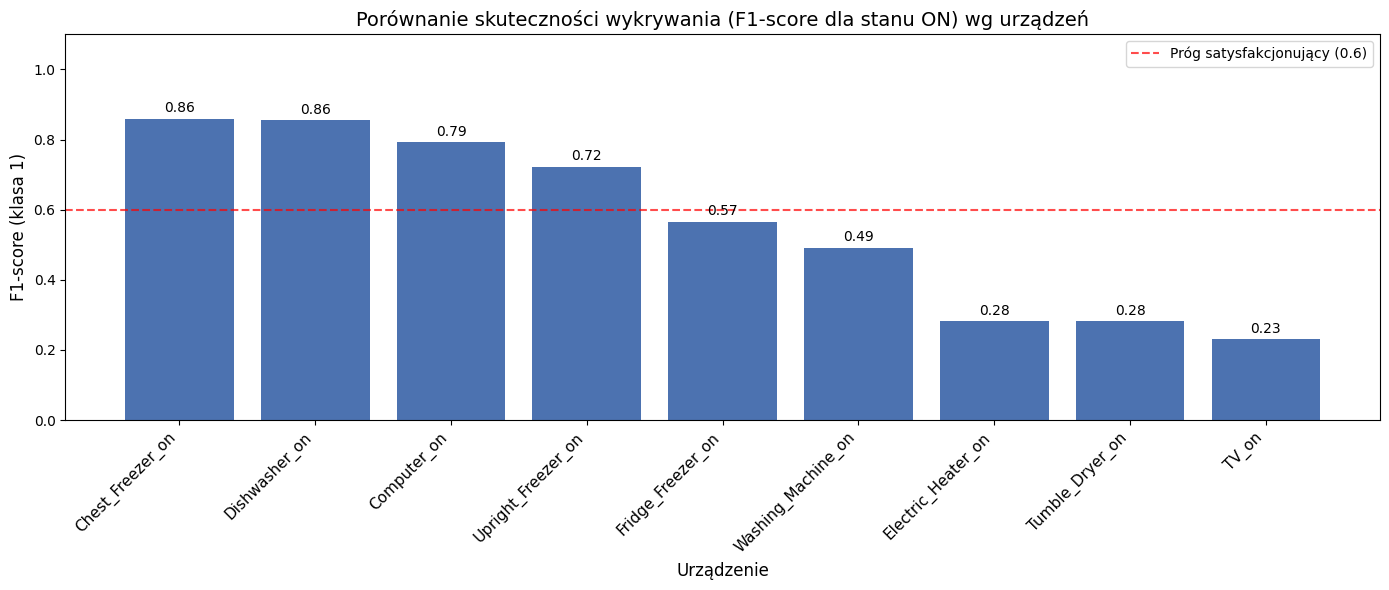

In [118]:
from scipy.signal import medfilt
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt

print("=== RAPORT EWALUACJI DLA WSZYSTKICH URZĄDZEŃ ===\n")

# Słownik do przechowywania wyników F1-score dla klasy 1, żebyśmy mogli je łatwo porównać na wykresie
f1_scores_class_1 = {}

# Pętla po wszystkich urządzeniach w zbiorze testowym
for appliance in y_test.columns:
    # Sprawdzamy, czy model dla tego urządzenia został poprawnie wytrenowany
    if appliance in models_dict:
        print(f"Ocenianie modelu dla: {appliance}")
        
        y_true = y_test[appliance]
        y_pred = y_pred_df[appliance].astype(int) # Upewniamy się, że to liczby całkowite
        
        # Przyjmujemy okno 11 próbek (czyli ok. 88 sekund obserwacji)
        # Rozmiar okna w filtrze medianowym musi być liczbą nieparzystą!
        window_size = 51

        # Zakładając, że Twoje oryginalne predykcje ze zbioru testowego to 'y_pred'
        y_pred = medfilt(y_pred, kernel_size=window_size)
        
        # Wyświetlamy tekstowy raport klasyfikacji
        raport = classification_report(y_true, y_pred, zero_division=0)
        print(raport)
        
        # Obliczamy i zapisujemy F1-score wyłącznie dla klasy 1 (czyli momentu, gdy sprzęt działa)
        f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        f1_scores_class_1[appliance] = f1
        print("-" * 50)

# ==========================================
# WIZUALIZACJA ZBIORCZA - WYKRES SŁUPKOWY
# ==========================================

# Sortujemy słownik od najwyższego do najniższego F1-score
sorted_f1 = dict(sorted(f1_scores_class_1.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(14, 6))
bars = plt.bar(sorted_f1.keys(), sorted_f1.values(), color='#4C72B0')

# Dodajemy czerwoną linię jako próg przyzwoitego wyniku (np. 0.6)
plt.axhline(y=0.6, color='red', linestyle='--', alpha=0.7, label='Próg satysfakcjonujący (0.6)')

# Dodajemy wartości liczbowe nad słupkami
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom', fontsize=10)

plt.title('Porównanie skuteczności wykrywania (F1-score dla stanu ON) wg urządzeń', fontsize=14)
plt.xlabel('Urządzenie', fontsize=12)
plt.ylabel('F1-score (klasa 1)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.ylim(0, 1.1) # Skala osi Y od 0 do 1.1 (z zapasem na tekst)
plt.legend()
plt.tight_layout()
plt.show()

In [119]:
import os
import joblib

# Tworzymy folder 'models' w obecnym katalogu roboczym
os.makedirs('models', exist_ok=True)

In [120]:
house = 4
for app in target_cols:
    # Generujemy nazwę pliku na podstawie nazwy urządzenia, np. "model_TV_on.joblib"
    filename = f"models/xgb_model_{app}_house{house}.joblib"
    if not os.path.exists(filename):
        # Zapisujemy model na dysk
        joblib.dump(models_dict[app], filename)
        print(f"Zapisano pomyślnie: {filename}")
    else:
        print(f"Model dla {app} już istnieje: {filename}. Pomijam zapis.")

Model dla Fridge_Freezer_on już istnieje: models/xgb_model_Fridge_Freezer_on_house4.joblib. Pomijam zapis.
Model dla Chest_Freezer_on już istnieje: models/xgb_model_Chest_Freezer_on_house4.joblib. Pomijam zapis.
Model dla Upright_Freezer_on już istnieje: models/xgb_model_Upright_Freezer_on_house4.joblib. Pomijam zapis.
Model dla Tumble_Dryer_on już istnieje: models/xgb_model_Tumble_Dryer_on_house4.joblib. Pomijam zapis.
Model dla Washing_Machine_on już istnieje: models/xgb_model_Washing_Machine_on_house4.joblib. Pomijam zapis.
Model dla Dishwasher_on już istnieje: models/xgb_model_Dishwasher_on_house4.joblib. Pomijam zapis.
Model dla Computer_on już istnieje: models/xgb_model_Computer_on_house4.joblib. Pomijam zapis.
Model dla TV_on już istnieje: models/xgb_model_TV_on_house4.joblib. Pomijam zapis.
Model dla Electric_Heater_on już istnieje: models/xgb_model_Electric_Heater_on_house4.joblib. Pomijam zapis.


In [121]:
# 1. Zabezpieczenie: upewniamy się, że zbiór treningowy ma poprawny format czasu
# Zakładam, że Twoje etykiety treningowe to y_train (DataFrame)
y_train.index = pd.to_datetime(y_train.index)

# 1. USTALENIE MAKSYMALNEJ PRZERWY W CYKLU (MOSTKOWANIE)
# Zakładamy, że jeśli pralka ma przerwę w pracy krótszą niż 30 minut, 
# to wciąż jest to ten SAM cykl prania. 
# Zmień na '60min' lub '15min' w zależności od potrzeb.
max_gap = '15min'

# Używamy okna kroczącego: jeśli w ciągu ostatnich 30 minut pojawiła się jakakolwiek 1,
# system zignoruje obecne 0 i potraktuje, że urządzenie wciąż pracuje.
y_train_continuous = y_train.rolling(window=max_gap, min_periods=1).max()

# 2. Wykrywamy momenty WŁĄCZENIA na prawdziwych danych historycznych
starts_train = (y_train_continuous.diff() == 1).astype(int)

# 3. Zliczamy uruchomienia w pełnych tygodniach
weekly_train_cycles = starts_train.resample('W').sum()

# 4. Automatyczne generowanie słownika nawyków
learned_habits = {}

print("--- WYUCZONE NAWYKI (ZBIÓR TRENINGOWY) ---")

for app in weekly_train_cycles.columns:
    # Pobieramy zliczenia dla danego urządzenia, usuwamy ewentualne puste tygodnie
    counts = weekly_train_cycles[app].dropna()
    
    # Odrzucamy 10% skrajnych wartości z dołu (np. wyjazdy) i 10% z góry (np. imprezy/goście)
    # i zaokrąglamy do pełnych liczb całkowitych
    min_typical = int(np.floor(counts.quantile(0.10)))
    max_typical = int(np.ceil(counts.quantile(0.90)))
    avg_typical = round(counts.mean(), 1)
    
    # Zapisujemy do słownika
    learned_habits[app] = {
        'min_weekly': min_typical,
        'max_weekly': max_typical,
        'avg_weekly': avg_typical
    }
    
    # Wyświetlamy dla wglądu
    print(f"{app.replace('_on', '')}:")
    print(f"  Średnio: {avg_typical} razy/tydzień")
    print(f"  Typowy zakres: od {min_typical} do {max_typical} razy\n")

--- WYUCZONE NAWYKI (ZBIÓR TRENINGOWY) ---
Fridge_Freezer:
  Średnio: 73.0 razy/tydzień
  Typowy zakres: od 25 do 116 razy

Chest_Freezer:
  Średnio: 80.3 razy/tydzień
  Typowy zakres: od 31 do 123 razy

Upright_Freezer:
  Średnio: 142.5 razy/tydzień
  Typowy zakres: od 36 do 208 razy

Tumble_Dryer:
  Średnio: 1.4 razy/tydzień
  Typowy zakres: od 0 do 3 razy

Washing_Machine:
  Średnio: 5.5 razy/tydzień
  Typowy zakres: od 0 do 13 razy

Dishwasher:
  Średnio: 8.8 razy/tydzień
  Typowy zakres: od 0 do 0 razy

Computer:
  Średnio: 21.2 razy/tydzień
  Typowy zakres: od 9 do 30 razy

TV:
  Średnio: 17.0 razy/tydzień
  Typowy zakres: od 2 do 27 razy

Electric_Heater:
  Średnio: 17.1 razy/tydzień
  Typowy zakres: od 2 do 27 razy



In [122]:
# 1. USTALENIE MAKSYMALNEJ PRZERWY W CYKLU (MOSTKOWANIE)
# Zakładamy, że jeśli pralka ma przerwę w pracy krótszą niż 30 minut, 
# to wciąż jest to ten SAM cykl prania. 
# Zmień na '60min' lub '15min' w zależności od potrzeb.
max_gap = '15min'

# Używamy okna kroczącego: jeśli w ciągu ostatnich 30 minut pojawiła się jakakolwiek 1,
# system zignoruje obecne 0 i potraktuje, że urządzenie wciąż pracuje.
y_pred_df_continuous = y_pred_df.rolling(window=max_gap, min_periods=1).max()
# 2. Wykrywamy momenty WŁĄCZENIA urządzenia
# Funkcja .diff() odejmuje poprzedni wiersz od obecnego. 
# Jeśli wczoraj było 0, a dziś jest 1, to 1 - 0 = 1 (URUCHOMIENIE!)
starts_df = (y_pred_df_continuous.diff() == 1).astype(int)

# 3. Agregujemy uruchomienia do pełnych tygodni ('W' od 'Weekly')
# Zliczamy sumę włączeń w każdym tygodniu
weekly_cycles = starts_df.resample('W').sum()

print("Przykładowe zliczone uruchomienia w poszczególnych tygodniach:")
print(weekly_cycles.head())

Przykładowe zliczone uruchomienia w poszczególnych tygodniach:
            Fridge_Freezer_on  Chest_Freezer_on  Upright_Freezer_on  \
Time                                                                  
2014-08-10                 82                45                  95   
2014-08-17                133                83                 170   
2014-08-24                106                72                 121   
2014-08-31                102                68                 104   
2014-09-07                117                72                 142   

            Tumble_Dryer_on  Washing_Machine_on  Dishwasher_on  Computer_on  \
Time                                                                          
2014-08-10                5                   8              0           43   
2014-08-17               12                  18              0           82   
2014-08-24                9                  12              0          105   
2014-08-31                6                 

In [123]:
print("\n--- RAPORT ZGODNOŚCI Z NAWYKAMI ---")

# Przechodzimy przez każdy tydzień w naszych zreprobkowanych danych
for week_date, row in weekly_cycles.iterrows():
    # Formatujemy datę dla czytelności (np. "2024-05-12")
    week_str = week_date.strftime('%Y-%m-%d')
    print(f"\nTydzień kończący się: {week_str}")
    
    # Sprawdzamy każde urządzenie zdefiniowane w słowniku nawyków
    for app, rules in learned_habits.items():
        if app in row.index:
            run_count = row[app]
            min_expected = rules['min_weekly']
            max_expected = rules['max_weekly']
            
            # Weryfikacja reguł
            if run_count < min_expected:
                status = "⚠️ ZA MAŁO"
                msg = f"(oczekiwano min. {min_expected})"
            elif run_count > max_expected:
                status = "⚠️ ZA DUŻO"
                msg = f"(oczekiwano max. {max_expected})"
            else:
                status = "✅ W NORMIE"
                msg = ""
                
            print(f"  - {app.replace('_on', '')}: uruchomiono {int(run_count)} razy | {status} {msg}")


--- RAPORT ZGODNOŚCI Z NAWYKAMI ---

Tydzień kończący się: 2014-08-10
  - Fridge_Freezer: uruchomiono 82 razy | ✅ W NORMIE 
  - Chest_Freezer: uruchomiono 45 razy | ✅ W NORMIE 
  - Upright_Freezer: uruchomiono 95 razy | ✅ W NORMIE 
  - Tumble_Dryer: uruchomiono 5 razy | ⚠️ ZA DUŻO (oczekiwano max. 3)
  - Washing_Machine: uruchomiono 8 razy | ✅ W NORMIE 
  - Dishwasher: uruchomiono 0 razy | ✅ W NORMIE 
  - Computer: uruchomiono 43 razy | ⚠️ ZA DUŻO (oczekiwano max. 30)
  - TV: uruchomiono 24 razy | ✅ W NORMIE 
  - Electric_Heater: uruchomiono 24 razy | ✅ W NORMIE 

Tydzień kończący się: 2014-08-17
  - Fridge_Freezer: uruchomiono 133 razy | ⚠️ ZA DUŻO (oczekiwano max. 116)
  - Chest_Freezer: uruchomiono 83 razy | ✅ W NORMIE 
  - Upright_Freezer: uruchomiono 170 razy | ✅ W NORMIE 
  - Tumble_Dryer: uruchomiono 12 razy | ⚠️ ZA DUŻO (oczekiwano max. 3)
  - Washing_Machine: uruchomiono 18 razy | ⚠️ ZA DUŻO (oczekiwano max. 13)
  - Dishwasher: uruchomiono 0 razy | ✅ W NORMIE 
  - Computer: u